In [139]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit, prange

We import necessary librarites.

numpy (np): Used for numerical operations and multi-dimensional arrays.

pandas (pd): Used for data manipulation and analysis using tables.

matplotlib (plt): Used for standard library for creating static, animated and visualizations.

time & os: Used for tools for measuring execution time.

In [140]:
RNG_TAG = 123                      # seed for Numba PRNG
WALL_SECONDS = 15 * 60.0           # 15 minutes

NEAR_CNT = 60                      # candidate list width (KNN)
START_TRIES = 220                  # number of NN starts
KICK_PERIOD = 45                   # snap back to best every K iterations
INIT_SWEEPS = 18                   # stronger init local search
RUN_SWEEPS = 4                     # cheaper per-iteration search

DRAW_PATH = True
SAVE_NAME = "tsp_best_15min_c_like.txt"
DEFAULT_DATA = "coordinates.csv"

• RNG_TAG = 123  
  Sets the random seed for the pseudo-random number generator to ensure reproducible results.

• WALL_SECONDS = 15 * 60.0  
  Defines the total runtime limit of the algorithm as 15 minutes (in seconds).

• NEAR_CNT = 60  
  Specifies the candidate list size (k-nearest neighbors) used to limit the search space and speed up local search.

• START_TRIES = 220  
  Number of nearest-neighbor (NN) starting solutions generated to improve the chance of finding a good initial tour.

• KICK_PERIOD = 45  
  After every 45 iterations, the algorithm resets (“kicks”) the current solution back to the best-known tour to avoid getting stuck in poor local minima.

• INIT_SWEEPS = 18  
  Number of intensive local search sweeps applied during the initialization phase to obtain a strong starting solution.

• RUN_SWEEPS = 4  
  Number of lighter, cheaper local search sweeps performed during each main iteration to refine the solution efficiently.

• DRAW_PATH = True  
  Enables visualization of the best tour path during or after the run.

• SAVE_NAME = "tsp_best_15min_c_like.txt"  
  Name of the output file where the best tour result will be saved.

• DEFAULT_DATA = "coordinates.csv"  
  Default input file containing the city coordinate data.

In [141]:
def pick_dataset():
    picks = []
    for fn in os.listdir("."):
        lo = fn.lower()
        if ("coord" in lo) and lo.endswith((".csv", ".txt")):
            picks.append(fn)
    if picks:
        picks.sort(key=len)
        return picks[0]
    return DEFAULT_DATA

pick_dataset searches the current directory for a dataset file.

All filenames in the directory are scanned.

Filenames are converted to lowercase for case insensitive matching.

Files containing the word "coord" and ending with .csv or .txt are selected.

Matching filenames are collected into a list.

If any matches are found, the shortest filename is chosen.

If no match is found, the default dataset name is returned.


In [142]:

def read_points(filepath):
    df = pd.read_csv(
        filepath,
        sep=r"[,\s]+",
        header=None,
        engine="python",
        encoding="utf-8-sig",
        comment="#",
        skip_blank_lines=True,
    )
    df = df.apply(pd.to_numeric, errors="coerce").dropna(how="all").reset_index(drop=True)

    if df.shape[1] > 3:
        df = df.iloc[:, :3]

    if df.shape[1] == 2:
        df.columns = ["x", "y"]
        df.insert(0, "id", np.arange(len(df), dtype=np.int32))
    else:
        df = df.iloc[:, :3].copy()
        df.columns = ["id", "x", "y"]

    df = df.dropna(subset=["x", "y"]).reset_index(drop=True)
    ids = df["id"].astype(np.int32).to_numpy()
    xy = df[["x", "y"]].astype(np.float64).to_numpy()
    return ids, xy


read_points loads city coordinate data from a file.

The file is read with flexible separators and no header.

Comments and blank lines are ignored.

All values are converted to numeric and empty rows are removed.

If more than three columns exist, extra columns are discarded.

If two columns exist, they are treated as x and y and an id column is created.

If three columns exist, they are treated as id, x, and y.

Rows with missing coordinates are removed.

City ids are returned as an int32 array.

Coordinates are returned as a float64 array.


In [143]:
def euclid_table(xy):
    x = xy[:, 0].astype(np.float32)
    y = xy[:, 1].astype(np.float32)
    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]
    return np.sqrt(dx * dx + dy * dy).astype(np.float32)


euclid_table computes the full pairwise Euclidean distance matrix.

The x and y coordinates are extracted from the input array.

Coordinates are converted to float32 for efficiency.

Pairwise differences in x and y directions are computed using broadcasting.

The Euclidean distance formula is applied to all pairs.

The resulting distance matrix is returned in float32 format.


In [144]:
@njit(fastmath=True, nogil=True, parallel=True)
def neighbor_buckets(dmat, width):
    n = dmat.shape[0]
    nn = np.empty((n, width), dtype=np.int32)

    for i in prange(n):
        row = dmat[i]
        idx = np.argpartition(row, width + 1)[: width + 1]  # includes self
        tmp = np.empty(width, dtype=np.int32)
        t = 0
        for j in range(idx.shape[0]):
            v = idx[j]
            if v != i:
                tmp[t] = v
                t += 1
                if t == width:
                    break

        # selection sort for k elements
        for a in range(width - 1):
            best = a
            bd = row[tmp[a]]
            for b in range(a + 1, width):
                d = row[tmp[b]]
                if d < bd:
                    bd = d
                    best = b
            if best != a:
                tmp[a], tmp[best] = tmp[best], tmp[a]

        nn[i] = tmp

    return nn

The function neighbor_buckets(dmat, width) builds a fixed-size nearest-neighbor list for each city using a distance matrix.

The @njit decorator compiles the function with Numba for high performance, enabling fast math operations, parallel execution, and releasing the GIL.

n is the number of cities, taken from the size of the distance matrix.

An empty integer array nn of shape (n, width) is created to store the nearest neighbors of each city.

The outer loop runs in parallel (prange), processing each city independently.

For each city i, the corresponding row of the distance matrix is selected.

np.argpartition is used to quickly find the (width + 1) smallest distances, which include the city itself.

A temporary array tmp is filled with the nearest neighbors excluding the city itself (v != i), stopping once width neighbors are collected.

A simple selection sort is applied to the tmp array to sort only the k selected neighbors by increasing distance.

The sorted neighbor list for city i is stored in nn[i].

The function returns nn, a matrix where each row contains the indices of the nearest neighbors for that city.


In [145]:
@njit(fastmath=True, nogil=True)
def cycle_cost(dmat, perm):
    n = perm.shape[0]
    s = 0.0
    for i in range(n - 1):
        s += dmat[perm[i], perm[i + 1]]
    s += dmat[perm[n - 1], perm[0]]
    return s

@njit(fastmath=True, nogil=True)
def flip_segment(perm, left, right):
    while left < right:
        perm[left], perm[right] = perm[right], perm[left]
        left += 1
        right -= 1

@njit(fastmath=True, nogil=True)
def delta_two_opt(dmat, perm, i, k):
    n = perm.shape[0]
    a = perm[i - 1]
    b = perm[i]
    c = perm[k]
    d = perm[(k + 1) % n]
    return (dmat[a, c] + dmat[b, d]) - (dmat[a, b] + dmat[c, d])

**1- Function cycle_cost :**

Computes the total length of a TSP tour.

It sums distances between consecutive cities.

It adds the distance from the last city back to the first.

It returns the total tour cost.

**2 - Function flip_segment:**

Reverses a segment of the tour in place.

The segment is defined by left and right indices.

It is used in 2-opt local search moves.

**3 - Function delta_two_opt:**

Computes the cost change of a 2-opt move.

It removes two edges and adds two new edges.

It avoids recomputing the full tour cost.

A negative result indicates an improving move.


In [146]:
@njit(fastmath=True, nogil=True)
def two_opt_guided(dmat, perm, knn, rounds):
    n = perm.shape[0]
    pos = np.empty(n, dtype=np.int32)
    for p in range(n):
        pos[perm[p]] = p

    score = cycle_cost(dmat, perm)

    for _ in range(rounds):
        changed = False
        for i in range(1, n):
            node = perm[i]
            for t in range(knn.shape[1]):
                mate = knn[node, t]
                k = pos[mate]
                if k == i or k == i - 1:
                    continue

                lo, hi = (i, k) if i < k else (k, i)
                if lo == 0:
                    lo = 1
                if lo >= hi:
                    continue

                dlt = delta_two_opt(dmat, perm, lo, hi)
                if dlt < -1e-9:
                    flip_segment(perm, lo, hi)
                    score += dlt
                    for z in range(lo, hi + 1):
                        pos[perm[z]] = z
                    changed = True
                    break

        if not changed:
            break

    return score

@njit(fastmath=True, nogil=True)
def nn_construct(dmat, knn, origin):
    n = dmat.shape[0]
    perm = np.empty(n, dtype=np.int32)
    seen = np.zeros(n, dtype=np.uint8)

    cur = origin
    perm[0] = cur
    seen[cur] = 1

    for i in range(1, n):
        nxt = -1
        best = 1e30

        # candidates first
        for t in range(knn.shape[1]):
            c = knn[cur, t]
            if seen[c] == 0:
                dd = dmat[cur, c]
                if dd < best:
                    best = dd
                    nxt = c

        # fallback scan
        if nxt == -1:
            for j in range(n):
                if seen[j] == 0:
                    dd = dmat[cur, j]
                    if dd < best:
                        best = dd
                        nxt = j

        cur = nxt
        perm[i] = cur
        seen[cur] = 1

    return perm

@njit(nogil=True)
def xorshift32(state):
    x = state
    x ^= (x << 13) & 0xFFFFFFFF
    x ^= (x >> 17) & 0xFFFFFFFF
    x ^= (x << 5)  & 0xFFFFFFFF
    return x & 0xFFFFFFFF

@njit(nogil=True)
def rand_int(state, lo, hi):
    state = xorshift32(state)
    return state, lo + (state % (hi - lo))

@njit(nogil=True)
def sort4(a, b, c, d):
    if a > b: a, b = b, a
    if c > d: c, d = d, c
    if a > c: a, c = c, a
    if b > d: b, d = d, b
    if b > c: b, c = c, b
    return a, b, c, d

**two_opt_guided function** applies a guided 2-opt local search to improve a TSP tour.

It keeps a position array to track each city’s index in the tour.
The initial tour cost is computed once at the beginning.

The algorithm runs for a fixed number of rounds or stops early if no improvement is found.

For each city, only k-nearest neighbor candidates are checked to reduce search cost.

Invalid or adjacent edge swaps are skipped.

If a 2-opt move reduces the tour length, the segment is reversed and the cost is updated incrementally.

Returns the final tour cost.

**nn_construct function** builds an initial tour using the nearest-neighbor heuristic.

The tour starts from a given origin city.

At each step, the closest unvisited city is selected from the KNN list first.

If no candidate is found, a full scan over all cities is used.

Each selected city is added to the tour and marked as visited.

The function returns the constructed tour permutation.

**xorshift32 function** implements a fast C-like pseudo-random number generator.

It updates the internal random state using bitwise operations.

**rand_int function** generates a pseudo-random integer in a given range.

It returns both the updated random state and the generated value.

**sort4 function** sorts four integers in ascending order.

It uses a fixed sequence of comparisons for efficiency.


In [147]:
@njit(nogil=True)
def unique4cuts(state, n):
    ok = False
    a = b = c = d = 1
    while not ok:
        state, a = rand_int(state, 1, n)
        state, b = rand_int(state, 1, n)
        state, c = rand_int(state, 1, n)
        state, d = rand_int(state, 1, n)
        ok = (a != b) and (a != c) and (a != d) and (b != c) and (b != d) and (c != d)
    a, b, c, d = sort4(a, b, c, d)
    return state, a, b, c, d

@njit(nogil=True)
def double_bridge_inplace(src, dst, a, b, c, d):
    n = src.shape[0]
    p = 0
    for i in range(0, a):
        dst[p] = src[i]; p += 1
    for i in range(b, c):
        dst[p] = src[i]; p += 1
    for i in range(a, b):
        dst[p] = src[i]; p += 1
    for i in range(c, d):
        dst[p] = src[i]; p += 1
    for i in range(d, n):
        dst[p] = src[i]; p += 1

@njit(nogil=True)
def copy_perm(dst, src):
    for i in range(src.shape[0]):
        dst[i] = src[i]

**unique4cuts** randomly selects four distinct cut positions in the tour.
It keeps sampling until all four indices are different.

The selected indices are sorted to maintain a valid order.

It returns the updated random state and the four cut points.

**double_bridge_inplace** applies a double-bridge move to a tour.

The tour is split into four segments using the cut points.
The segments are reordered to strongly perturb the tour.

The result is written into the destination array in place.

**copy_perm** copies one permutation array into another.

It performs an element by element copy.

It is used to duplicate tours efficiently without reallocation.


In [148]:
def final_summaries(best_val, seed_val, n, out_name):
    lines = [
        f"Run finished. Best tour length: {best_val:.6f} (seed={seed_val}, n={n}). Output: {out_name}.",
        f"Completed search: distance = {best_val:.6f}. Instance size n={n}; seed={seed_val}. Saved -> {out_name}.",
        f"End of run, Best distance achieved is {best_val:.6f}. Seed={seed_val}, nodes={n}. File: {out_name}.",
        f"Optimization terminated. Best objective value: {best_val:.6f}. (n={n}, seed={seed_val}) written to {out_name}.",
        f"Summary: best={best_val:.6f} | seed={seed_val} | n={n} | exported={out_name}.",
    ]
    print("\n" + "=" * 70)
    for i, msg in enumerate(lines, 1):
        print(f"[Final {i}] {msg}")
    print("=" * 70 + "\n")


**final_summaries** generates and prints end of run summary messages.

It formats multiple summary strings using the best result, seed, problem size, and output file name.

The best tour length is displayed with six decimal precision.

A visual separator line is printed before the summaries.

Each summary line is printed with an index label.

A closing separator line is printed at the end.

The function provides a clear and consistent final report of the run.


Instance file: coordinates.csv
Node count: 532
t=   16.3s | best=  5864.6171 | cur=  5864.6171 | it=9098 | left=  883.7s
t=   31.3s | best=  5828.4462 | cur=  5828.4462 | it=18943 | left=  868.7s
t=   46.3s | best=  5816.4790 | cur=  5816.4790 | it=28961 | left=  853.7s
t=   61.3s | best=  5801.7352 | cur=  5801.7352 | it=38667 | left=  838.7s
t=   76.3s | best=  5791.7125 | cur=  5791.7125 | it=48726 | left=  823.7s
t=   91.3s | best=  5791.4664 | cur=  5791.4664 | it=58920 | left=  808.7s
t=  106.3s | best=  5788.9653 | cur=  5788.9653 | it=68630 | left=  793.7s
t=  121.3s | best=  5788.9653 | cur=  5788.9653 | it=78766 | left=  778.7s
t=  136.3s | best=  5788.9653 | cur=  5788.9653 | it=88779 | left=  763.7s
t=  151.3s | best=  5788.9653 | cur=  5788.9653 | it=97841 | left=  748.7s
t=  166.3s | best=  5788.9653 | cur=  5788.9653 | it=107975 | left=  733.7s
t=  181.3s | best=  5788.9653 | cur=  5788.9653 | it=117991 | left=  718.7s
t=  196.3s | best=  5788.9653 | cur=  5788.9653 | it

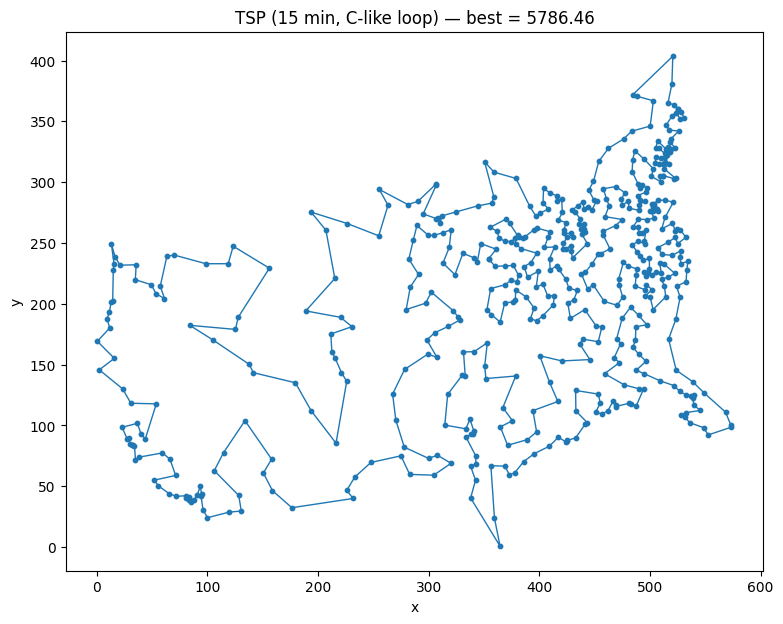

In [149]:
def run_15min_c_like():
    data_file = pick_dataset()
    print("Instance file:", data_file)

    city_ids, xy = read_points(data_file)
    n = xy.shape[0]
    print("Node count:", n)

    dmat = euclid_table(xy)
    k = min(NEAR_CNT, n - 1)
    knn = neighbor_buckets(dmat, k)

    t0 = time.time()
    t_stop = t0 + WALL_SECONDS

    py_rng = np.random.default_rng(RNG_TAG)
    tries = min(START_TRIES, n)
    anchors = py_rng.choice(np.arange(n), size=tries, replace=False)

    incumbent = None
    incumbent_val = 1e30

    for s in anchors:
        perm = nn_construct(dmat, knn, int(s))
        val = float(two_opt_guided(dmat, perm, knn, INIT_SWEEPS))
        if val < incumbent_val:
            incumbent_val = val
            incumbent = perm.copy()
        if time.time() >= t_stop:
            break

    if incumbent is None:
        perm = nn_construct(dmat, knn, int(py_rng.integers(0, n)))
        incumbent_val = float(two_opt_guided(dmat, perm, knn, INIT_SWEEPS))
        incumbent = perm.copy()

    current = incumbent.copy()
    current_val = float(incumbent_val)

    candidate = np.empty_like(current)

    state = np.uint32(RNG_TAG)

    it = 0
    last_log = time.time()

    while time.time() < t_stop:
        it += 1

        # fully compiled random cut generation
        state, a, b, c, d = unique4cuts(state, n)

        # fully compiled kick + reuse buffer
        double_bridge_inplace(current, candidate, a, b, c, d)

        cand_val = float(two_opt_guided(dmat, candidate, knn, RUN_SWEEPS))

        if cand_val < current_val - 1e-9:
            copy_perm(current, candidate)
            current_val = cand_val

        if cand_val < incumbent_val - 1e-9:
            incumbent_val = cand_val
            incumbent = candidate.copy()

        if it % KICK_PERIOD == 0:
            current = incumbent.copy()
            current_val = float(incumbent_val)
            candidate = np.empty_like(current)  # keep buffer consistent

        if time.time() - last_log > 15:
            elapsed = time.time() - t0
            remain = max(0.0, t_stop - time.time())
            print(f"t={elapsed:7.1f}s | best={incumbent_val:11.4f} | cur={current_val:11.4f} | it={it} | left={remain:7.1f}s")
            last_log = time.time()

    best_ids = city_ids[incumbent].reshape(-1)

    with open(SAVE_NAME, "w", encoding="utf-8") as f:
        f.write(f"Best Distance: {incumbent_val:.6f}\n")
        f.write(f"Seed: {RNG_TAG}\n")
        f.write(f"n: {n}\n")
        f.write("Tour IDs (cycle):\n")
        f.write(" ".join(map(str, best_ids.tolist())) + "\n")
        f.write(str(best_ids[0]) + "\n")

    final_summaries(incumbent_val, RNG_TAG, n, SAVE_NAME)

    if DRAW_PATH:
        order = np.append(incumbent, incumbent[0])
        plt.figure(figsize=(9, 7))
        plt.scatter(xy[:, 0], xy[:, 1], s=10)
        plt.plot(xy[order, 0], xy[order, 1], linewidth=1)
        plt.title(f"TSP (15 min, C-like loop) — best = {incumbent_val:.2f}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()

    return incumbent, incumbent_val, best_ids

best_perm, best_cost, best_id_order = run_15min_c_like()

**run_15min_c_like** is the main driver function that executes the TSP heuristic for a fixed time limit.

It automatically selects the dataset file and reads city IDs, coordinates.

The distance matrix is computed and k nearest neighbor lists are built.

The total runtime is limited using WALL_SECONDS.

An initial pool of starting cities is generated using a Python random generator.

For each start, a nearest neighbor tour is constructed and improved with guided 2 opt.

The best initial solution is stored.

If no incumbent is found, a random start is used as fallback.

The current solution is initialized from the incumbent.

A reusable candidate buffer is allocated to avoid repeated memory allocation.

A Numba based pseudo random number generator state is initialized for the hot loop.

The main loop runs until the time limit is reached.

In each iteration, four random cut points are generated.

A double bridge move is applied to strongly perturb the current tour.

The perturbed tour is locally optimized with a limited number of 2 opt sweeps.

If the candidate improves the current solution, it is accepted.

If the candidate improves the global best solution, the incumbent is updated.

Every fixed number of iterations, the search snaps back to the best solution found so far.

Progress information is printed periodically.

After the run, the best tour is written to an output file.

A final summary message is printed.

If drawing is enabled, the best tour is visualized.

The function returns the best tour permutation, its cost, and the ordered city IDs.

The script ends by calling run_15min_c_like to start the optimization.
